In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet50, ResNet50_Weights
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import copy, time

In [3]:
# ── Transforms ──────────────────────────────────────────────
train_transform = T.Compose([
    T.Resize(256),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

In [4]:
# ── Dataset ──────────────────────────────────────────────────
full_dataset = OxfordIIITPet(root='./data', download=True)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")

# Split into train/val manually so we can apply different transforms
all_indices = list(range(len(full_dataset)))
val_size = int(0.2 * len(all_indices))
train_size = len(all_indices) - val_size

torch.manual_seed(42)
train_indices, val_indices = random_split(all_indices, [train_size, val_size])

class PetSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = list(indices)
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        img, label = self.dataset[self.indices[i]]
        return self.transform(img), label

train_set = PetSubset(full_dataset, train_indices, train_transform)
val_set   = PetSubset(full_dataset, val_indices,   val_transform)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=0)

print(f"Train: {len(train_set)}, Val: {len(val_set)}")

Classes (37): ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']
Train: 2944, Val: 736


In [5]:
# ── Model ────────────────────────────────────────────────────
# Start from ImageNet pretrained weights — only replace the final layer
weights = ResNet50_Weights.IMAGENET1K_V2
model = resnet50(weights=weights)

# Freeze all layers except the final classifier
for param in model.parameters():
    param.requires_grad = False

# Replace final layer — this one is trainable
model.fc = nn.Linear(model.fc.in_features, num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")
model = model.to(device)

Training on: cpu


In [6]:
# Test 1: can we load a single item?
import time
t0 = time.time()
img, label = full_dataset[0]
print(f"Single item load: {time.time()-t0:.2f}s, label: {label}")

Single item load: 0.12s, label: 0


In [7]:
# Test 2: can we iterate one batch manually?
t0 = time.time()
imgs, labels = next(iter(train_loader))
print(f"First batch: {time.time()-t0:.2f}s, shape: {imgs.shape}")

First batch: 0.28s, shape: torch.Size([32, 3, 224, 224])


In [8]:
class CachedPetSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.transform = transform
        print("Caching dataset in memory...")
        self.images = []
        self.labels = []
        for i, idx in enumerate(indices):
            img, label = dataset[idx]
            self.images.append(img)
            self.labels.append(label)
            if i % 500 == 0:
                print(f"  {i}/{len(indices)}")
        print("Done.")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        return self.transform(self.images[i]), self.labels[i]

train_set = CachedPetSubset(full_dataset, train_indices, train_transform)
val_set   = CachedPetSubset(full_dataset, val_indices,   val_transform)

Caching dataset in memory...
  0/2944
  500/2944
  1000/2944
  1500/2944
  2000/2944
  2500/2944
Done.
Caching dataset in memory...
  0/736
  500/736
Done.


In [ ]:
# Resume from checkpoint
USE_CHECKPOINT = False

if USE_CHECKPOINT:
    checkpoint = torch.load('oxford_pets_checkpoint.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    history = checkpoint['history']
    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['val_accuracy']
    best_weights = checkpoint['best_model_state_dict']
    print(f"Resuming from epoch {start_epoch}")
else:
    start_epoch = 0
    print("Starting over")

In [9]:
# ── Training ─────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, epoch, total_epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)
        correct += (out.argmax(1) == labels).sum().item()
        total += len(imgs)
        if batch_idx % 20 == 0:
            print(f"  Epoch {epoch}/{total_epochs} "
                  f"batch {batch_idx}/{len(loader)} "
                  f"loss {loss.item():.3f}") #, end='\r')
    print()
    return total_loss/total, correct/total

def val_epoch(model, loader, epoch, total_epochs):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch_idx, (imgs, labels) in enumerate(loader):
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * len(imgs)
            correct += (out.argmax(1) == labels).sum().item()
            total += len(imgs)
            if batch_idx % 20 == 0:
                print(f"  VAL epoch {epoch}/{total_epochs} "
                      f"batch {batch_idx}/{len(loader)} "
                      f"loss {loss.item():.3f}") #, end='\r')
    return total_loss/total, correct/total

EPOCHS = 8
history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
best_acc = 0
best_weights = None

print("\nTraining...")
for epoch in range(start_epoch, EPOCHS):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, epoch, EPOCHS)
    vl_loss, vl_acc = val_epoch(model, val_loader, epoch, EPOCHS)
    scheduler.step()
    elapsed = time.time() - t0

    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)

    # Save best model
    if vl_acc > best_acc:
        best_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"train loss {tr_loss:.3f} acc {tr_acc:.1%} | "
          f"val loss {vl_loss:.3f} acc {vl_acc:.1%} | "
          f"{elapsed:.0f}s")

    # Save after every epoch, not just at the end
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'best_model_state_dict': best_weights,
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'class_names': class_names,
        'val_accuracy': best_acc,
    }, 'oxford_pets_checkpoint.pth')
    print(f"Checkpoint saved (epoch {epoch+1})")

print(f"\nBest val accuracy: {best_acc:.1%}")


Training...
  Epoch 0/8 batch 80/92 loss 1.231
Epoch 1/8 | train loss 2.137 acc 62.8% | val loss 1.155 acc 86.7% | 359s
  Epoch 1/8 batch 80/92 loss 0.658
Epoch 2/8 | train loss 0.795 acc 90.0% | val loss 0.662 acc 90.5% | 347s
  Epoch 2/8 batch 80/92 loss 0.415
Epoch 3/8 | train loss 0.486 acc 92.5% | val loss 0.476 acc 90.5% | 355s
  Epoch 3/8 batch 80/92 loss 0.283
Epoch 4/8 | train loss 0.378 acc 94.2% | val loss 0.425 acc 92.4% | 382s
  Epoch 4/8 batch 80/92 loss 0.286
Epoch 5/8 | train loss 0.336 acc 94.4% | val loss 0.399 acc 92.1% | 647s
  Epoch 5/8 batch 80/92 loss 0.347
Epoch 6/8 | train loss 0.298 acc 95.1% | val loss 0.367 acc 92.9% | 404s
  Epoch 6/8 batch 80/92 loss 0.269
Epoch 7/8 | train loss 0.269 acc 95.9% | val loss 0.354 acc 92.9% | 356s
  Epoch 7/8 batch 80/92 loss 0.249
Epoch 8/8 | train loss 0.256 acc 95.8% | val loss 0.342 acc 92.9% | 359s

Best val accuracy: 92.9%


In [10]:
# Load best weights
model.load_state_dict(best_weights)

# Save model
torch.save({
    'model_state_dict': best_weights,
    'class_names': class_names,
    'val_accuracy': best_acc,
}, 'oxford_pets_resnet50_backup.pth')
print("Saved to oxford_pets_resnet50_backup.pth")

Saved to oxford_pets_resnet50.pth


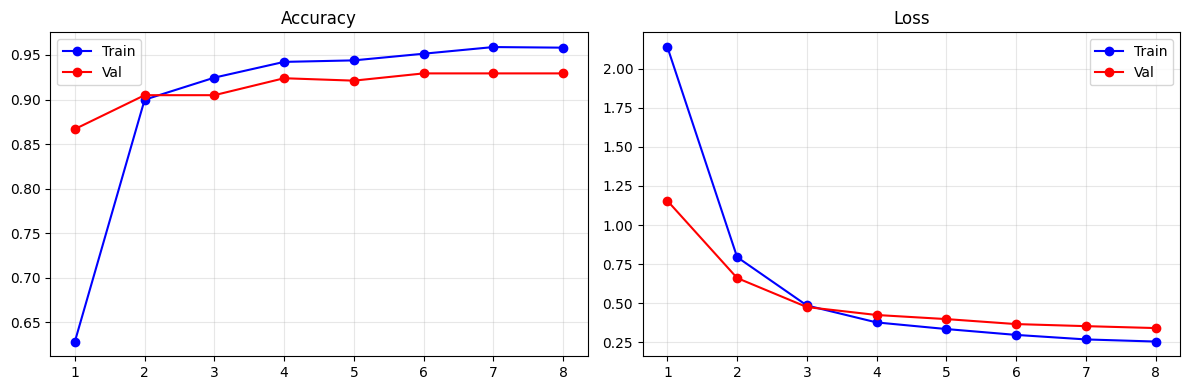

In [11]:
# ── Learning curves ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, EPOCHS+1)
ax1.plot(epochs, history['train_acc'], 'b-o', label='Train')
ax1.plot(epochs, history['val_acc'],   'r-o', label='Val')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(epochs, history['train_loss'], 'b-o', label='Train')
ax2.plot(epochs, history['val_loss'],   'r-o', label='Val')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [1]:
print("Kernel ready")

Kernel ready
